In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
plt.style.use('fivethirtyeight')
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.tools as tls
from mpl_toolkits.basemap import Basemap
import folium
import folium.plugins
from matplotlib import animation,rc
import io
import base64
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

In [2]:
ebay = pd.read_csv('C:\\Users\\Zhuldyz\\Downloads/ebay_merged_data.csv')
ebay.head()

,category,title,price,condition,sold_date,shipping,rating,reviews_count,seller_feedback_percentage,seller_feedback_rating,seller_feedback_count,url
0,external_hd,Crucial X10 Pro - 4TB 3.2 USB-C Portable Exter...,$350.00,Brand New,4-Mar-26,+$31.50 delivery,5.0,6.0,99.7,positive,10100,https://www.ebay.com/itm/137086133076?_skw=ext...
1,external_hd,SanDisk Extreme V2 1TB USB-C Portable External...,$90.00,Brand New,4-Mar-26,+$26.72 delivery,5.0,59.0,100.0,positive,43,https://www.ebay.com/itm/127719406867?_skw=ext...
2,external_hd,Promise Pegasus R4 External 4-Bay Thunderbolt ...,$99.99,Pre-Owned,4-Mar-26,+$186.52 delivery,NaN,NaN,99.5,positive,5400,https://www.ebay.com/itm/389138379334?_skw=ext...
3,external_hd,Seagate Expansion 10TB External Desktop HDD US...,$150.05,Pre-Owned,4-Mar-26,+$36.36 delivery,NaN,NaN,0.0,positive,0,https://www.ebay.com/itm/389671388128?_skw=ext...
4,external_hd,Seagate Expansion 10TB External Desktop HDD US...,$202.50,Pre-Owned,4-Mar-26,+$36.36 delivery,NaN,NaN,0.0,positive,0,https://www.ebay.com/itm/389671368101?_skw=ext...


In [3]:
ebay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35429 entries, 0 to 35428
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   category                    35429 non-null  object 
 1   title                       35429 non-null  object 
 2   price                       35428 non-null  object 
 3   condition                   34758 non-null  object 
 4   sold_date                   35429 non-null  object 
 5   shipping                    35045 non-null  object 
 6   rating                      11258 non-null  float64
 7   reviews_count               10495 non-null  float64
 8   seller_feedback_percentage  33561 non-null  float64
 9   seller_feedback_rating      33561 non-null  object 
 10  seller_feedback_count       33561 non-null  object 
 11  url                         35429 non-null  object 
dtypes: float64(3), object(9)
memory usage: 3.2+ MB


In [7]:
ebay['category'].unique()

array(['external_hd', 'gaming_headset', 'gaming_keyboard', 'gaming_mouse'],
      dtype=object)

In [9]:
ebay['title'].nunique()

25558

In [10]:
ebay['title'].value_counts()

New KingSpec Z5 4TB Portable External SSD w/ RGB - USB 3.2 Gen2x2 - Fast Ship       63
SanDisk Extreme V2 1TB USB-C Portable External SSD (SDSSDE61-1T00-G25)              57
Logitech G502 HERO Wired Gaming Mouse - 910-005469                                  43
Logitech G502 X PLUS Wireless Gaming Mouse - Black                                  37
SanDisk Extreme PRO V2 4TB USB-C Portable External SSD (SDSSDE81-4T00-G25)          36
                                                                                    ..
LOT (6) External HD Hard Drives Maxtor Western Digital Seagate UNTESTED PoR F113     1
WD 3 TB My Passport For Mac USB 3.0 Desktop Hard Drive                               1
WD My Passport Ultra 1 TB USB 3.0 external HD                                        1
Iomega eGo 500GB Portable External Hard Drive USB 2.0 FireWire New Sealed            1
Keychron M6 Wireless Gaming Optical Mouse Open Box New 2.4G Bluetooth Black          1
Name: title, Length: 25558, dtype: int64

In [14]:
ebay['price'] = pd.to_numeric(
    ebay['price'].str.replace(r'[$,]', '', regex=True),
    errors='coerce'
)

In [15]:
top_products = (
    ebay.groupby('title')
      .agg(avg_price=('price', 'mean'), count=('title', 'count'))
      .sort_values(by='count', ascending=False)
      .reset_index()
)

In [19]:
top_products.head(20)

,title,avg_price,count
0,New KingSpec Z5 4TB Portable External SSD w/ R...,187.412698,63
1,SanDisk Extreme V2 1TB USB-C Portable External...,100.435263,57
2,Logitech G502 HERO Wired Gaming Mouse - 910-00...,21.406047,43
3,Logitech G502 X PLUS Wireless Gaming Mouse - B...,85.377297,37
4,SanDisk Extreme PRO V2 4TB USB-C Portable Exte...,328.606389,36
5,Samsung T7 2TB Portable External SSD - Blue (M...,144.295143,35
6,"SanDisk 2TB, External,2.5 inch (SDSSDE61-2T00-...",154.100857,35
7,WD Elements 20TB USB 3.0 Desktop External Hard...,230.976071,28
8,SanDisk Extreme PRO V2 2TB USB-C Portable Exte...,172.951852,27
9,SanDisk 2TB Extreme Portable External SSD SDSS...,130.691600,25


<Axes: >

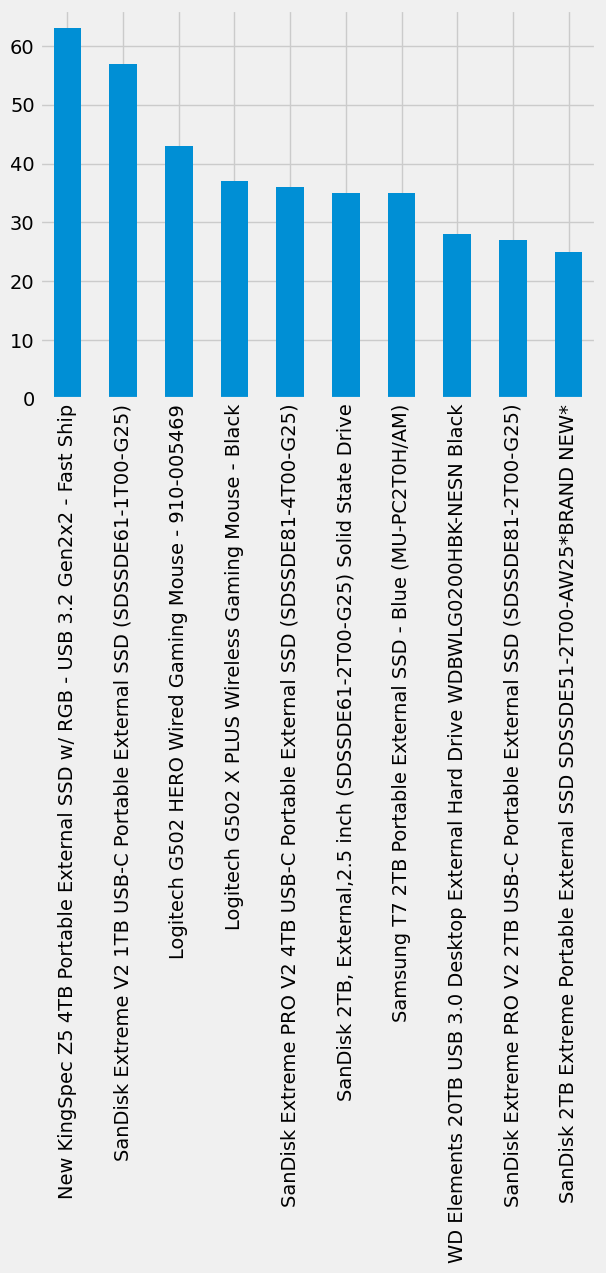

In [23]:
top_products = ebay['title'].value_counts().head(10)

top_products.plot(kind='bar')

<Axes: >

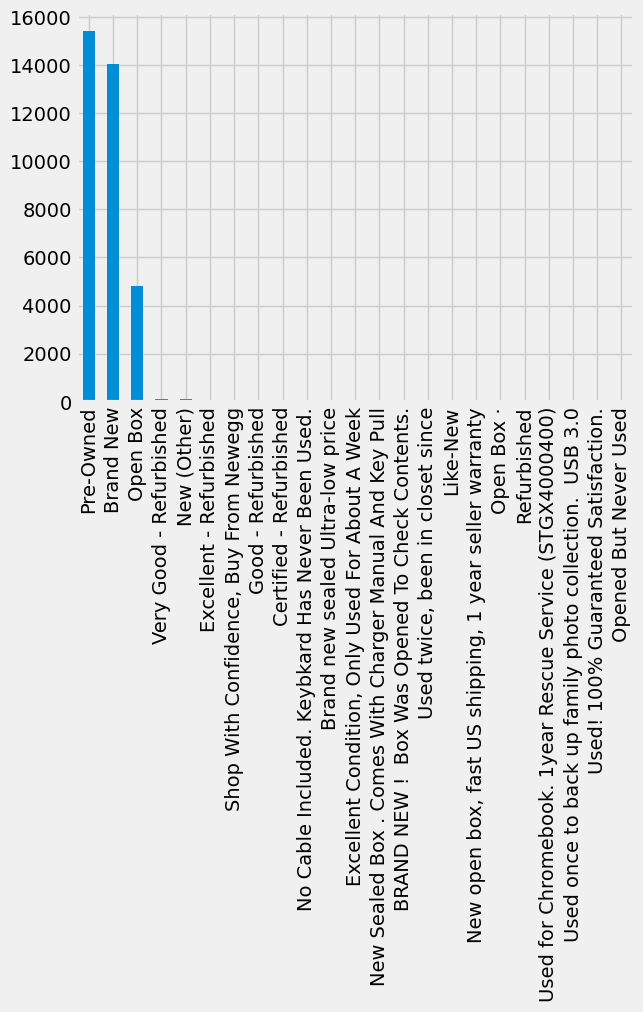

In [31]:
ebay['condition'].value_counts().plot(kind='bar')

<Axes: xlabel='condition'>

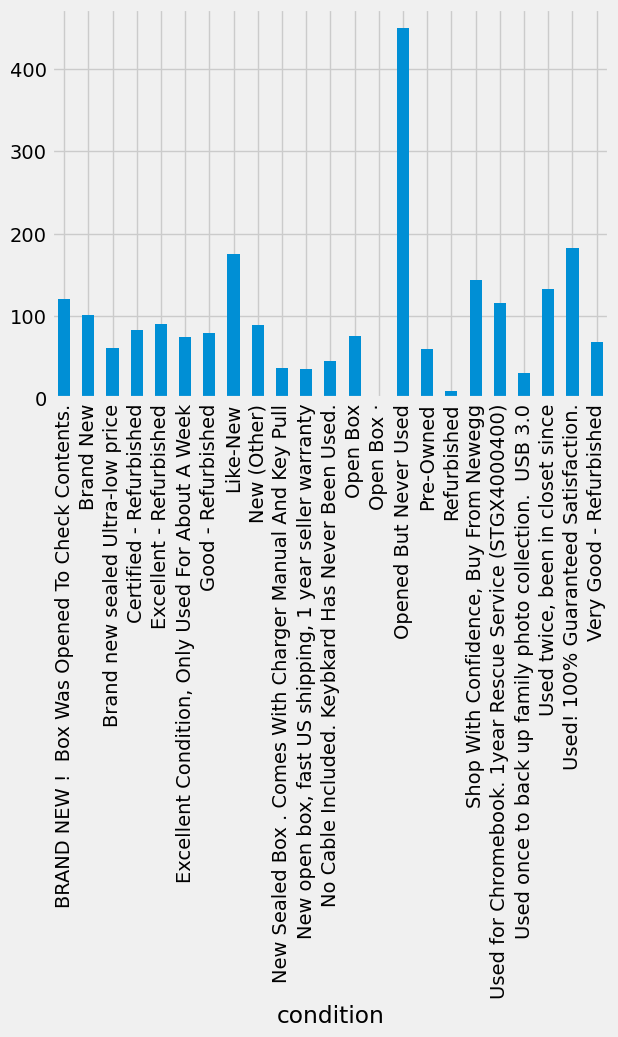

In [32]:
ebay.groupby('condition')['price'].mean().plot(kind='bar')

<Axes: xlabel='category_code', ylabel='price'>

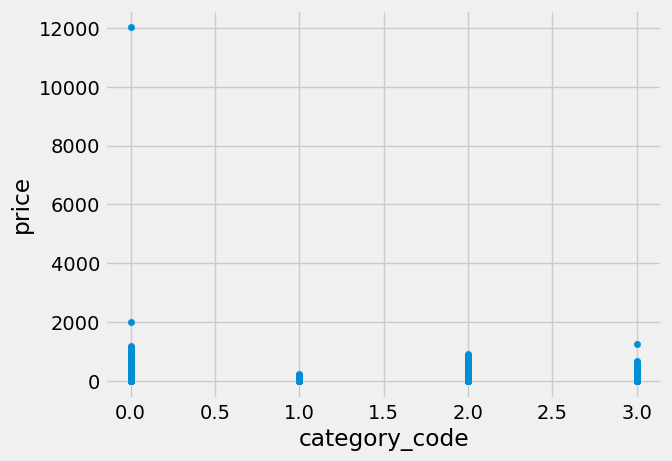

In [33]:
ebay['category_code'] = ebay['category'].astype('category').cat.codes
ebay.plot.scatter(x='category_code', y='price')

<Axes: title={'center': 'Mean price in categories'}, xlabel='category'>

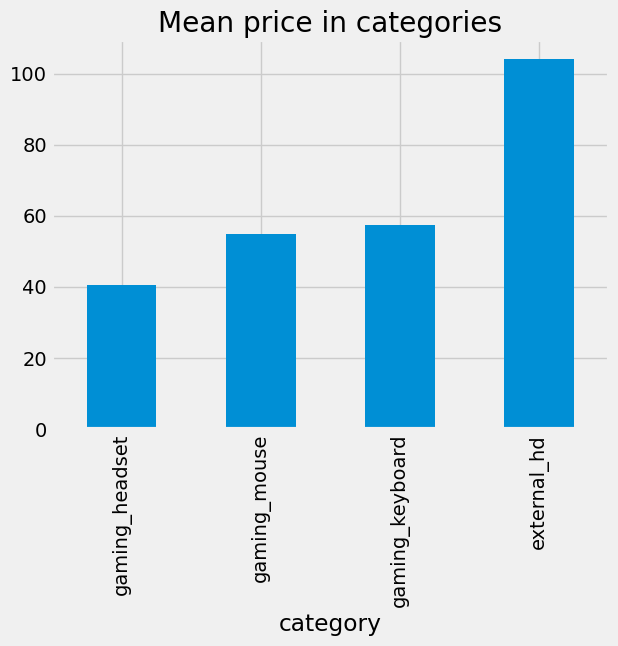

In [35]:
ebay.groupby('category')['price'].mean().sort_values().plot(
    kind='bar', title='Mean price in categories'
)

<Axes: title={'center': 'price distribution'}, ylabel='Frequency'>

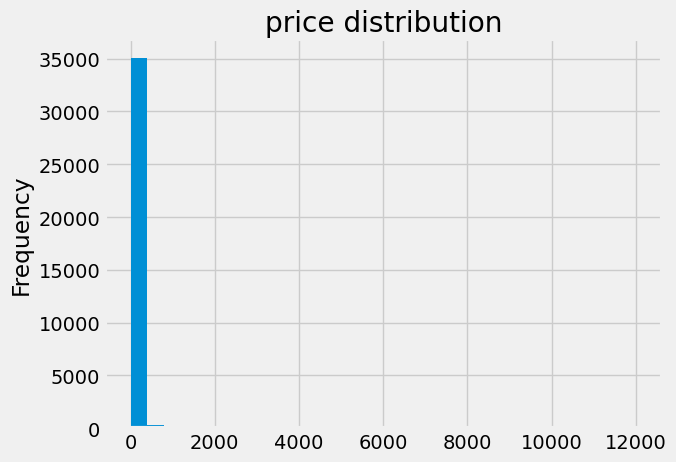

In [36]:
ebay['price'].plot(kind='hist', bins=30, title='price distribution')